In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as mticker

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 11,
    'axes.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
})

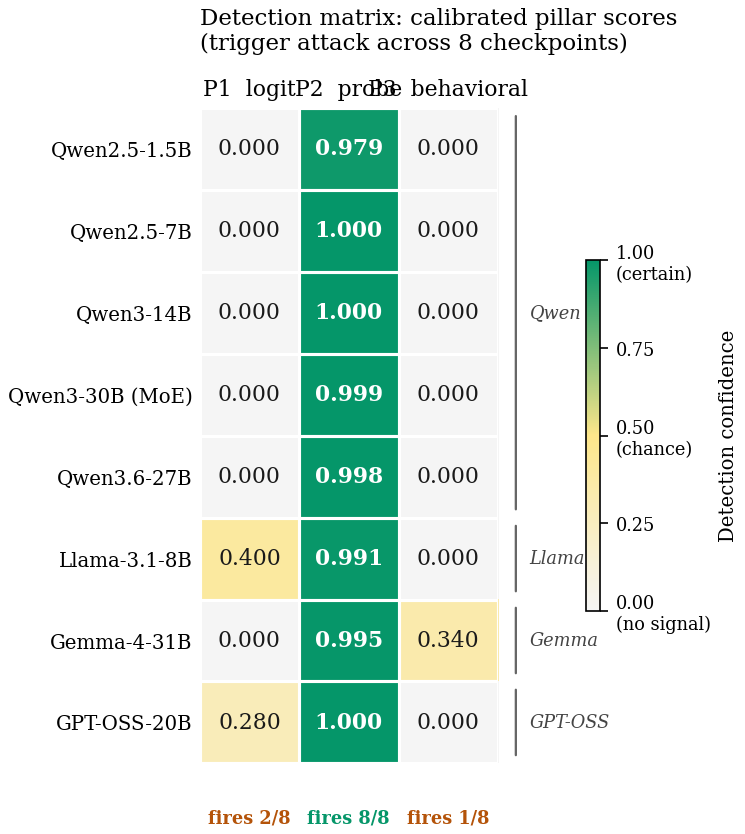

In [2]:
# ── Fig 1: Detection matrix heatmap ───────────────────────────────────────────

models = [
    'Qwen2.5-1.5B', 'Qwen2.5-7B', 'Qwen3-14B',
    'Qwen3-30B (MoE)', 'Qwen3.6-27B',
    'Llama-3.1-8B', 'Gemma-4-31B', 'GPT-OSS-20B'
]
pillars = ['P1  logit', 'P2  probe', 'P3  behavioral']
families = ['Qwen'] * 5 + ['Llama', 'Gemma', 'GPT-OSS']

scores = np.array([
    [0.000, 0.979, 0.000],
    [0.000, 1.000, 0.000],
    [0.000, 1.000, 0.000],
    [0.000, 0.999, 0.000],
    [0.000, 0.998, 0.000],
    [0.400, 0.991, 0.000],
    [0.000, 0.995, 0.340],
    [0.280, 1.000, 0.000],
])

cmap = LinearSegmentedColormap.from_list(
    'detect', ['#f5f5f5', '#fde68a', '#059669'], N=512
)

fig, ax = plt.subplots(figsize=(5.2, 5.8))

im = ax.imshow(scores, cmap=cmap, vmin=0, vmax=1, aspect='auto')

# Cell text
for i in range(len(models)):
    for j in range(len(pillars)):
        v = scores[i, j]
        txt_color = 'white' if v > 0.55 else '#1a1a1a'
        weight = 'bold' if v > 0.9 else 'normal'
        ax.text(j, i, f'{v:.3f}', ha='center', va='center',
                fontsize=10.5, color=txt_color, fontweight=weight)

# Grid lines between cells
for i in range(len(models) + 1):
    ax.axhline(i - 0.5, color='white', linewidth=1.5)
for j in range(len(pillars) + 1):
    ax.axvline(j - 0.5, color='white', linewidth=1.5)

ax.set_xticks(range(len(pillars)))
ax.set_xticklabels(pillars, fontsize=10.5)
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')

ax.set_yticks(range(len(models)))
ax.set_yticklabels(models, fontsize=9.5)

# Family brackets on the right
family_spans = [('Qwen', 0, 4), ('Llama', 5, 5), ('Gemma', 6, 6), ('GPT-OSS', 7, 7)]
for fam, start, end in family_spans:
    mid = (start + end) / 2
    x0 = len(pillars) - 0.4
    ax.annotate('', xy=(x0 + 0.08, end + 0.45),
                xytext=(x0 + 0.08, start - 0.45),
                xycoords='data', annotation_clip=False,
                arrowprops=dict(arrowstyle='-', color='#666', lw=1.1))
    ax.text(x0 + 0.22, mid, fam, va='center', ha='left',
            fontsize=8.5, color='#444', clip_on=False, style='italic')

# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.22, aspect=25)
cbar.set_label('Detection confidence', fontsize=9.5)
cbar.ax.tick_params(labelsize=8.5)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.set_ticklabels(['0.00\n(no signal)', '0.25', '0.50\n(chance)', '0.75', '1.00\n(certain)'])

# "Fires" summary row
fires = (scores > 0.01).sum(axis=0)
for j, f in enumerate(fires):
    ax.text(j, len(models) + 0.05, f'fires {f}/8',
            ha='center', va='top', fontsize=8.5,
            color='#059669' if f == 8 else '#b45309',
            fontweight='bold', clip_on=False)

ax.set_xlim(-0.5, len(pillars) - 0.5)
ax.set_ylim(len(models) - 0.5, -0.5)
ax.tick_params(length=0)
ax.set_frame_on(False)

ax.set_title('Detection matrix: calibrated pillar scores\n(trigger attack across 8 checkpoints)',
             fontsize=11, pad=28, loc='left')

plt.tight_layout()
plt.savefig('fig2_detection_matrix.pdf')
plt.show()

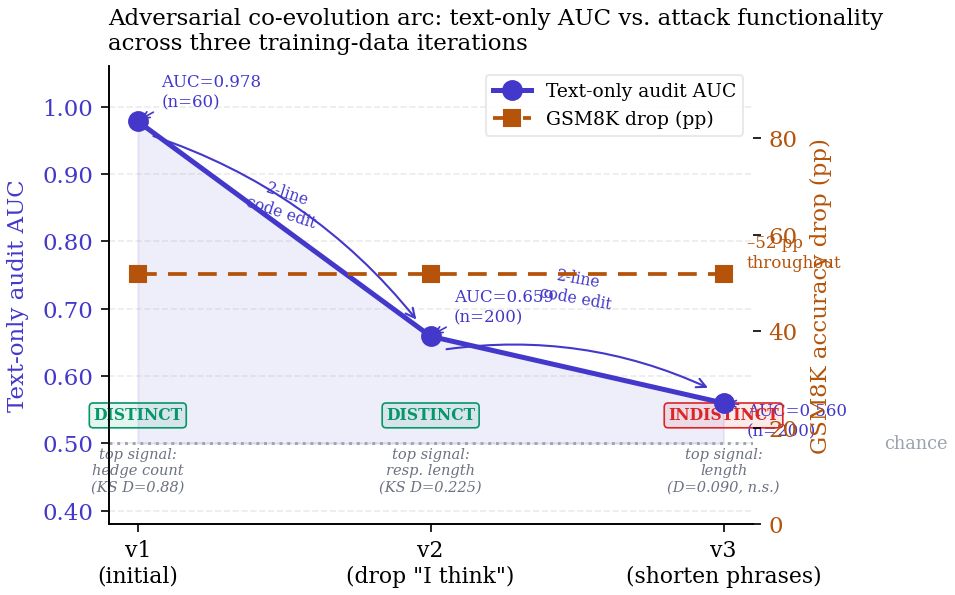

In [3]:
# ── Fig 2: Co-evolution arc ────────────────────────────────────────────────────

versions   = ['v1\n(initial)', 'v2\n(drop "I think")', 'v3\n(shorten phrases)']
auc_vals   = [0.978, 0.659, 0.560]
gsm8k_drop = [52,    52,    52]
top_feats  = ['hedge count\n(KS D=0.88)', 'resp. length\n(KS D=0.225)', 'length\n(D=0.090, n.s.)']
verdicts   = ['DISTINCT', 'DISTINCT', 'INDISTINCT']
n_vals     = [60, 200, 200]
x = np.arange(len(versions))

fig, ax1 = plt.subplots(figsize=(6.8, 4.2))
ax2 = ax1.twinx()

# AUC shaded area
ax1.fill_between(x, auc_vals, 0.5, alpha=0.09, color='#4338ca')

# AUC line
ax1.plot(x, auc_vals, 'o-', color='#4338ca', linewidth=2.4,
         markersize=9, zorder=4, label='Text-only audit AUC')

# AUC point annotations
for i, (v, n) in enumerate(zip(auc_vals, n_vals)):
    offset = 0.022 if i < 2 else -0.048
    ax1.annotate(f'AUC={v:.3f}\n(n={n})',
                 xy=(i, v), xytext=(i + 0.08, v + offset),
                 fontsize=8, color='#4338ca',
                 arrowprops=dict(arrowstyle='->', color='#4338ca',
                                 lw=0.8, connectionstyle='arc3,rad=0.1'))

# Chance baseline
ax1.axhline(0.5, color='#9ca3af', linestyle=':', linewidth=1.4, zorder=1)
ax1.text(2.55, 0.50, 'chance', va='center', fontsize=8.5, color='#9ca3af', clip_on=False)

# Verdict badges
verdict_colors = {'DISTINCT': '#059669', 'INDISTINCT': '#dc2626'}
for i, vd in enumerate(verdicts):
    col = verdict_colors[vd]
    ax1.text(i, 0.535, vd, ha='center', fontsize=7.5, color=col,
             fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.25', fc=col + '18', ec=col, lw=0.8))

# Top feature annotation below x-axis
for i, feat in enumerate(top_feats):
    ax1.text(i, 0.43, f'top signal:\n{feat}', ha='center', fontsize=7,
             color='#6b7280', style='italic', clip_on=False)

# GSM8K drop (right axis)
ax2.plot(x, gsm8k_drop, 's--', color='#b45309', linewidth=1.8,
         markersize=8, zorder=3, dashes=(5, 3), label='GSM8K drop (pp)')
ax2.text(2.08, 52.5, '–52 pp\nthroughout', fontsize=8,
         color='#b45309', va='bottom', clip_on=False)

ax1.set_xticks(x)
ax1.set_xticklabels(versions, fontsize=10.5)
ax1.set_ylabel('Text-only audit AUC', fontsize=11, color='#4338ca', labelpad=6)
ax1.set_ylim(0.38, 1.06)
ax1.tick_params(axis='y', labelcolor='#4338ca')
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

ax2.set_ylabel('GSM8K accuracy drop (pp)', fontsize=11, color='#b45309', labelpad=6)
ax2.set_ylim(0, 95)
ax2.tick_params(axis='y', labelcolor='#b45309')
ax2.spines['top'].set_visible(False)
ax2.grid(False)
ax2.set_yticks([0, 20, 40, 60, 80])

# Edit cost annotations (arrows between versions)
for i in range(len(x) - 1):
    ax1.annotate('', xy=(i + 1 - 0.04, auc_vals[i + 1] + 0.02),
                 xytext=(i + 0.04, auc_vals[i] - 0.02),
                 arrowprops=dict(arrowstyle='->', color='#4338ca',
                                 lw=1.0, connectionstyle='arc3,rad=-0.15'))
ax1.text(0.5, 0.82, '2-line\ncode edit', ha='center', fontsize=7.5,
         color='#4338ca', rotation=-18)
ax1.text(1.5, 0.70, '2-line\ncode edit', ha='center', fontsize=7.5,
         color='#4338ca', rotation=-10)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9,
           loc='upper right', framealpha=0.9, edgecolor='#e5e7eb')

ax1.set_title('Adversarial co-evolution arc: text-only AUC vs. attack functionality\nacross three training-data iterations',
              fontsize=11, loc='left', pad=8)
ax1.grid(True, alpha=0.25, linestyle='--', which='major', axis='y')

plt.tight_layout()
plt.savefig('fig1_coevolution.pdf')
plt.show()

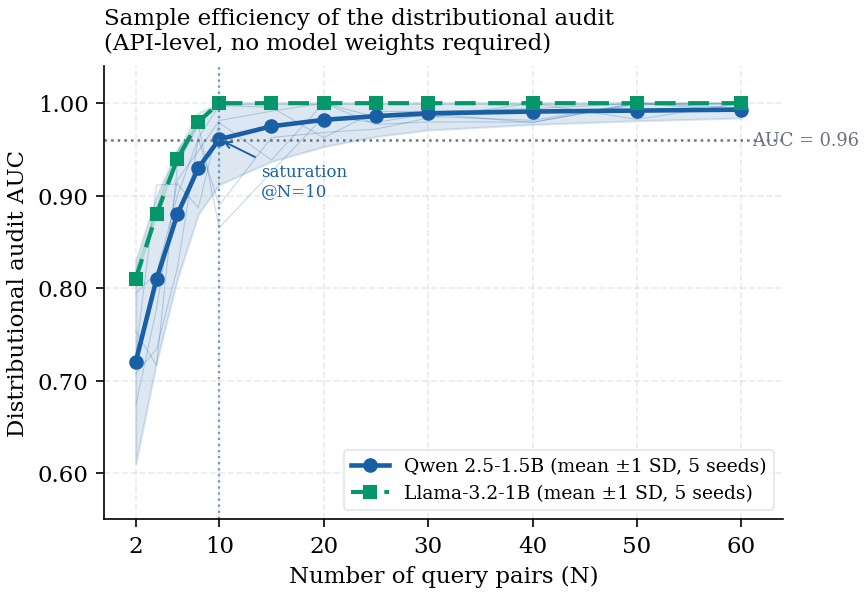

In [4]:
# ── Fig 3: Sample efficiency ───────────────────────────────────────────────────

n_pairs  = np.array([2, 4, 6, 8, 10, 15, 20, 25, 30, 40, 50, 60])
mean_q   = np.array([0.720, 0.810, 0.880, 0.930, 0.961,
                     0.975, 0.982, 0.986, 0.989, 0.991, 0.992, 0.993])
sd_q     = np.array([0.110, 0.090, 0.070, 0.050, 0.049,
                     0.038, 0.029, 0.022, 0.018, 0.014, 0.011, 0.009])
mean_l   = np.array([0.810, 0.880, 0.940, 0.980, 1.000,
                     1.000, 1.000, 1.000, 1.000, 1.000, 1.000, 1.000])
sd_l     = np.zeros(len(n_pairs))

fig, ax = plt.subplots(figsize=(6.0, 4.2))

# Qwen band + line
ax.fill_between(n_pairs, np.minimum(mean_q + sd_q, 1.0), mean_q - sd_q,
                alpha=0.15, color='#185FA5', label='_nolegend_')
ax.plot(n_pairs, mean_q, 'o-', color='#185FA5', linewidth=2.2,
        markersize=6, label='Qwen 2.5-1.5B (mean ±1 SD, 5 seeds)')

# Llama line
ax.plot(n_pairs, mean_l, 's--', color='#059669', linewidth=2.0,
        markersize=6, dashes=(5, 3), label='Llama-3.2-1B (mean ±1 SD, 5 seeds)')
ax.fill_between(n_pairs, np.minimum(mean_l + 0.01, 1.0), mean_l,
                alpha=0.12, color='#059669', label='_nolegend_')

# Threshold line
ax.axhline(0.96, color='#6b7280', linestyle=':', linewidth=1.2)
ax.text(61, 0.96, 'AUC = 0.96', va='center', fontsize=8.5,
        color='#6b7280', clip_on=False)

# Saturation marker
ax.axvline(10, color='#185FA5', linestyle=':', linewidth=1.1, alpha=0.6)
ax.annotate('saturation\n@N=10', xy=(10, 0.961), xytext=(14, 0.90),
            fontsize=8, color='#185FA5',
            arrowprops=dict(arrowstyle='->', color='#185FA5', lw=0.9))

# Individual seed scatter (simulated) for Qwen
rng = np.random.default_rng(42)
for seed in range(5):
    seed_auc = np.clip(mean_q + rng.normal(0, sd_q), 0, 1)
    ax.plot(n_pairs, seed_auc, '-', color='#185FA5',
            linewidth=0.5, alpha=0.25, zorder=1)

ax.set_xlabel('Number of query pairs (N)', fontsize=11)
ax.set_ylabel('Distributional audit AUC', fontsize=11)
ax.set_ylim(0.55, 1.04)
ax.set_xlim(-1, 64)
ax.set_xticks([2, 10, 20, 30, 40, 50, 60])
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.legend(fontsize=9, framealpha=0.9, edgecolor='#e5e7eb', loc='lower right')
ax.set_title('Sample efficiency of the distributional audit\n(API-level, no model weights required)',
             fontsize=11, loc='left', pad=8)
ax.grid(True, alpha=0.25, linestyle='--')

plt.tight_layout()
plt.savefig('fig3_sample_efficiency.pdf')
plt.show()

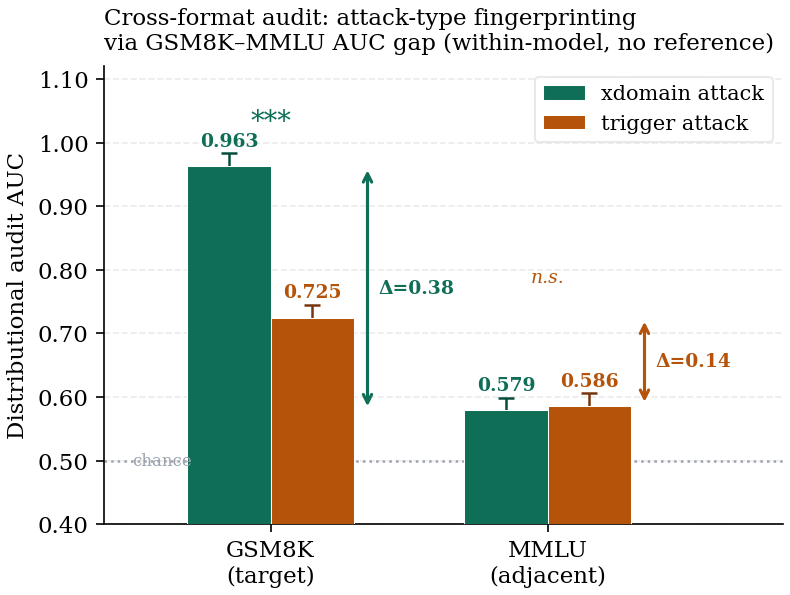

In [5]:
# ── Fig 4: Cross-format audit ──────────────────────────────────────────────────

benchmarks     = ['GSM8K\n(target)', 'MMLU\n(adjacent)']
xdomain_scores = [0.963, 0.579]
trigger_scores = [0.725, 0.586]

x     = np.arange(len(benchmarks))
width = 0.3

fig, ax = plt.subplots(figsize=(5.5, 4.2))

bars1 = ax.bar(x - width/2, xdomain_scores, width,
               color='#0F6E56', label='xdomain attack', zorder=3,
               edgecolor='white', linewidth=0.5)
bars2 = ax.bar(x + width/2, trigger_scores, width,
               color='#b45309', label='trigger attack', zorder=3,
               edgecolor='white', linewidth=0.5)

# Error bars (illustrative ±0.02 CI)
ax.errorbar(x - width/2, xdomain_scores, yerr=0.02,
            fmt='none', color='#064e3b', capsize=4, linewidth=1.2, capthick=1.2)
ax.errorbar(x + width/2, trigger_scores, yerr=0.02,
            fmt='none', color='#78350f', capsize=4, linewidth=1.2, capthick=1.2)

# Value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.025,
            f'{bar.get_height():.3f}', ha='center', va='bottom',
            fontsize=9, color='#0F6E56', fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.025,
            f'{bar.get_height():.3f}', ha='center', va='bottom',
            fontsize=9, color='#b45309', fontweight='bold')

# Δ gap arrows
def draw_gap_arrow(x_pos, y_low, y_high, delta_str, color, x_offset=0.25):
    ax.annotate('', xy=(x_pos + x_offset, y_high),
                xytext=(x_pos + x_offset, y_low),
                arrowprops=dict(arrowstyle='<->', color=color,
                                lw=1.5, mutation_scale=10))
    ax.text(x_pos + x_offset + 0.04, (y_low + y_high) / 2,
            delta_str, va='center', fontsize=9,
            color=color, fontweight='bold')

draw_gap_arrow(0, xdomain_scores[1], xdomain_scores[0], 'Δ=0.38', '#0F6E56', x_offset=0.35)
draw_gap_arrow(1, trigger_scores[1],  trigger_scores[0],  'Δ=0.14', '#b45309', x_offset=0.35)

# Significance annotation
ax.text(0, 1.02, '***', ha='center', fontsize=13, color='#0F6E56')
ax.text(1, 0.78, 'n.s.', ha='center', fontsize=9, color='#b45309', style='italic')

# Chance line
ax.axhline(0.5, color='#9ca3af', linestyle=':', linewidth=1.2)
ax.text(-0.5, 0.50, 'chance', va='center', fontsize=8, color='#9ca3af', clip_on=False)

ax.set_xticks(x)
ax.set_xticklabels(benchmarks, fontsize=11)
ax.set_ylabel('Distributional audit AUC', fontsize=11)
ax.set_ylim(0.4, 1.12)
ax.set_xlim(-0.6, 1.85)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.legend(fontsize=10, framealpha=0.9, edgecolor='#e5e7eb', loc='upper right')
ax.set_title('Cross-format audit: attack-type fingerprinting\nvia GSM8K–MMLU AUC gap (within-model, no reference)',
             fontsize=11, loc='left', pad=8)
ax.grid(True, alpha=0.25, linestyle='--', axis='y')

plt.tight_layout()
plt.savefig('fig4_crossformat.pdf')
plt.show()